# MD Analysis Notebook

Uses `md.py` as the simulation engine. Typical workflow:
1. Define a potential
2. Set up initial conditions
3. Run the simulation (`performance=False` for progress bar, `True` for max speed)
4. Analyse the trajectory

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from md import MD, HarmonicPotential, Timer

/Users/sebastian/Documents/work/learning/learning_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Define a potential

Any callable `potential(r_i)` where `r_i` has shape `(3,)` and returns a scalar.
JAX autodiffs through it automatically to get forces.

In [2]:
# Built-in harmonic: V(r) = 0.5 * k * ||r - r0||^2
potential = HarmonicPotential(k=1.0, r0=0.0)

# Custom example — uncomment to use instead:
# def lj_potential(r, eps=1.0, sigma=1.0):
#     d = jnp.linalg.norm(r)
#     sr6 = (sigma / d) ** 6
#     return 4 * eps * (sr6**2 - sr6)
# potential = lj_potential

## 2. Initial conditions

In [3]:
N  = 50
dt = 0.01
m  = 1.0

key = jax.random.PRNGKey(42)
key_r, key_v, key_a = jax.random.split(key, 3)

r0 = jax.random.normal(key_r, (N, 3)) * 0.5
v0 = jax.random.normal(key_v, (N, 3)) * 0.1
a0 = jnp.zeros((N, 3))

print(f"r0: {r0.shape}, v0: {v0.shape}, a0: {a0.shape}")

r0: (50, 3), v0: (50, 3), a0: (50, 3)


## 3. Run — with progress bar (default)

In [4]:
sim = MD(r0, v0, a0, potential, dt=dt, m=m)

with Timer("MD run (progress mode)"):
    traj = sim.run(n_steps=500, chunk_size=50)  # progress=True by default

print(f"positions trajectory : {traj['positions'].shape}")  # (500, N, 3)
print(f"final positions      : {sim.r.shape}")

MD simulation: 100%|██████████| chunk 10/10  [00:00<00:00, 226.94chunk/s]

[MD run (progress mode)] elapsed: 0.0622s
positions trajectory : (500, 50, 3)
final positions      : (50, 3)


## 3b. Run — performance mode (single lax.scan, no overhead)

In [5]:
sim_fast = MD(r0, v0, a0, potential, dt=dt, m=m)

with Timer("MD run (performance mode)"):
    traj_fast = sim_fast.run(n_steps=500, performance=True)

print(f"positions trajectory : {traj_fast['positions'].shape}")

[MD run (performance mode)] elapsed: 0.0437s
positions trajectory : (500, 50, 3)


## 4. Save & reload trajectory

In [6]:
sim.save_trajectory('trajectory')

loaded = MD.load_trajectory('trajectory.npz')
print({k: v.shape for k, v in loaded.items()})

Trajectory saved to trajectory.npz
{'positions': (500, 50, 3), 'velocities': (500, 50, 3), 'accelerations': (500, 50, 3)}


## 5. Analysis

### Kinetic energy

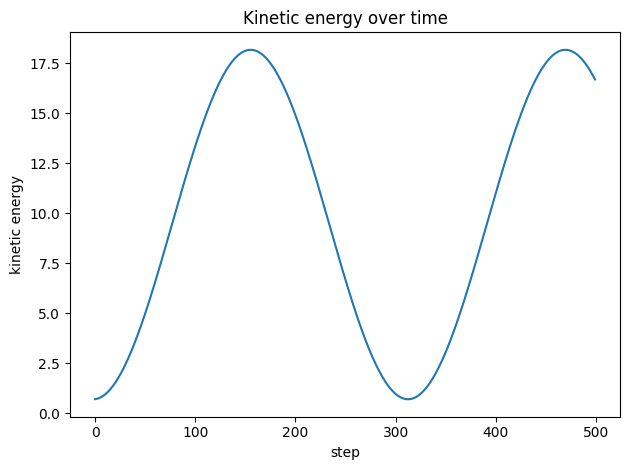

In [7]:
v_traj = traj['velocities']                              # (n_steps, N, 3)
ke     = 0.5 * m * np.sum(v_traj ** 2, axis=(1, 2))     # (n_steps,)

plt.figure()
plt.plot(ke)
plt.xlabel('step')
plt.ylabel('kinetic energy')
plt.title('Kinetic energy over time')
plt.tight_layout()
plt.show()

### Mean squared displacement (MSD)

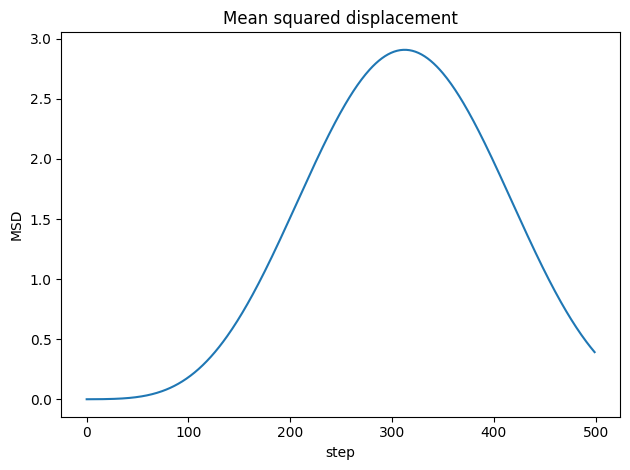

In [8]:
r_traj = traj['positions']                               # (n_steps, N, 3)
disp   = r_traj - r_traj[0]                             # displacement from t=0
msd    = np.mean(np.sum(disp ** 2, axis=-1), axis=-1)   # (n_steps,)

plt.figure()
plt.plot(msd)
plt.xlabel('step')
plt.ylabel('MSD')
plt.title('Mean squared displacement')
plt.tight_layout()
plt.show()

### Timing: JIT warm-up vs. steady state vs. performance mode

In [9]:
import time

def bench(n_steps, performance, chunk_size=50):
    s = MD(r0, v0, a0, potential, dt=dt, m=m)
    # warm up JIT with a tiny run so timing reflects steady state
    s.run(n_steps=chunk_size, performance=performance, chunk_size=chunk_size)
    # timed run
    s2 = MD(r0, v0, a0, potential, dt=dt, m=m)
    t0 = time.perf_counter()
    s2.run(n_steps=n_steps, performance=performance, chunk_size=chunk_size)
    return time.perf_counter() - t0

n = 500
t_progress    = bench(n, performance=False, chunk_size=50)
t_performance = bench(n, performance=True)

print(f"progress mode    : {t_progress:.3f}s")
print(f"performance mode : {t_performance:.3f}s")
print(f"overhead         : {100*(t_progress - t_performance)/t_performance:+.1f}%")

MD simulation: 100%|██████████| chunk 1/1  [00:00<00:00, 15.94chunk/s]
MD simulation: 100%|██████████| chunk 10/10  [00:00<00:00, 306.00chunk/s]

progress mode    : 0.034s
performance mode : 0.029s
overhead         : +14.9%
